## 导入基础库

In [1]:
import numpy as np                          # 导入 NumPy，用于数值计算
import pandas as pd                         # 导入 Pandas，用于数据读取与处理（DataFrame）
from sklearn.decomposition import PCA       # 导入 PCA（主成分分析），用于数据降维
from sklearn.cluster import KMeans          # 导入 KMeans 聚类算法
import matplotlib.pyplot as plt             # 导入 Matplotlib，用于数据可视化
from sklearn.metrics import silhouette_score # 导入轮廓系数，用于评估聚类效果

## 读取订单-商品关联表（prior）

In [2]:
# 读取四张表的数据，这里先读取 prior 表
# prior 表记录了历史订单中每个订单包含的商品（订单id 与 商品id 的对应关系）
prior = pd.read_csv('./data/instacart/order_products__prior.csv')
# pd.read_csv: 读取 CSV 文件，返回 DataFrame
#   参数: 文件路径（str）
#   返回: DataFrame，列包含 order_id、product_id、add_to_cart_order、reordered

## 读取商品信息表（products）

In [3]:
# products 表记录商品 id 与所属货架（aisle）的对应关系
products = pd.read_csv('./data/instacart/products.csv')
# 返回 DataFrame，列包含 product_id、product_name、aisle_id、department_id

## 读取订单信息表（orders）

In [4]:
# orders 表记录订单 id 与用户 id 的对应关系（文件较大）
orders = pd.read_csv('./data/instacart/orders.csv')
# 返回 DataFrame，列包含 order_id、user_id、eval_set、order_number 等

## 读取货架分类表（aisles）

In [5]:
# aisles 表记录超市货架 id 与该货架所放商品类别（类别名称）的对应关系
aisles = pd.read_csv('./data/instacart/aisles.csv')
# 返回 DataFrame，列包含 aisle_id、aisle（货架类别名称）

## 预览 prior 表前5行

In [6]:
prior.head()  # head() 默认返回前5行，展示 DataFrame 的列结构（订单id、商品id等）
# 本项目只需关注 order_id 与 product_id 的对应关系

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


## 预览 products 表前5行

In [7]:
products.head()  # 查看商品表前5行，展示 product_id、product_name、aisle_id 等字段

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


## 预览 orders 表前5行

In [8]:
orders.head()  # 查看订单表前5行，展示 order_id、user_id 等字段

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


## 预览 aisles 表前5行

In [9]:
aisles.head()  # 查看货架表前5行，展示 aisle_id 和 aisle（货架类别名称）字段

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


## 合并四张表为「用户-商品类别」宽表

In [10]:
# 目标：将四张表合并为一张，建立「用户 - 商品类别」的关联
# 逻辑：用户买了哪些订单 → 订单包含哪些商品 → 商品属于哪个货架 → 货架对应哪种品类
_ = pd.merge(prior, products, on=['product_id', 'product_id'])
# pd.merge: 按公共键合并两个 DataFrame（类似 SQL JOIN）
#   on='product_id': 以 product_id 列作为连接键（str 或 list）
#   返回: 包含 prior 和 products 所有列的 DataFrame
_mg = pd.merge(_, orders, on=['order_id', 'order_id'])
# 再将上步结果与 orders 表按 order_id 合并，加入用户信息
mt = pd.merge(_mg, aisles, on=['aisle_id', 'aisle_id'])
# 最后与 aisles 表按 aisle_id 合并，加入货架类别名称
# 最终 mt 是包含14列的大表，记录每个用户每笔订单对应的商品及其所属类别

## 查看合并后大表的形状

In [12]:
mt.shape  # 返回 (行数, 列数) 的元组（tuple），行为订单-商品记录数，列为合并后的字段数

(32434489, 14)

## 预览合并后大表前10行

In [11]:
mt.head(10)  # 返回 DataFrame 的前10行，参数10为行数（int），默认为5

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle
0,2,33120,1,1,Organic Egg Whites,86,16,202279,prior,3,5,9,8.0,eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,202279,prior,3,5,9,8.0,fresh vegetables
2,2,9327,3,0,Garlic Powder,104,13,202279,prior,3,5,9,8.0,spices seasonings
3,2,45918,4,1,Coconut Butter,19,13,202279,prior,3,5,9,8.0,oils vinegars
4,2,30035,5,0,Natural Sweetener,17,13,202279,prior,3,5,9,8.0,baking ingredients
5,2,17794,6,1,Carrots,83,4,202279,prior,3,5,9,8.0,fresh vegetables
6,2,40141,7,1,Original Unflavored Gelatine Mix,105,13,202279,prior,3,5,9,8.0,doughs gelatins bake mixes
7,2,1819,8,1,All Natural No Stir Creamy Almond Butter,88,13,202279,prior,3,5,9,8.0,spreads
8,2,43668,9,0,Classic Blend Cole Slaw,123,4,202279,prior,3,5,9,8.0,packaged vegetables fruits
9,3,33754,1,1,Total 2% with Strawberry Lowfat Greek Strained...,120,16,205970,prior,16,5,17,12.0,yogurt


## 计算各列数据缺失率

In [13]:
mt.isnull().sum() / mt.shape[0]  # 计算各列缺失率
# mt.isnull(): 返回与 mt 同形状的布尔 DataFrame，缺失值处为 True
# .sum(): 对每列求和（True=1），得到各列缺失值数量（Series）
# / mt.shape[0]: 除以总行数，得到各列缺失率（float）
# 结果中 days_since_prior_order 约有 6.4% 缺失（第一次下单无上次时间）

order_id                  0.00000
product_id                0.00000
add_to_cart_order         0.00000
reordered                 0.00000
product_name              0.00000
aisle_id                  0.00000
department_id             0.00000
user_id                   0.00000
eval_set                  0.00000
order_number              0.00000
order_dow                 0.00000
order_hour_of_day         0.00000
days_since_prior_order    0.06407
aisle                     0.00000
dtype: float64

## 选取 user_id 和 aisle_id 两列查看

In [16]:
mt.loc[:, ['user_id', 'aisle_id']].head(50)
# mt.loc[行索引, 列索引]: 按标签选取数据
#   ':': 选取所有行
#   ['user_id','aisle_id']: 只选这两列（list of str）
# .head(50): 只显示前50行，便于观察用户与货架的对应关系

,user_id,aisle_id
0,202279,86
1,202279,83
2,202279,104
3,202279,19
4,202279,17
5,202279,83
6,202279,105
7,202279,88
8,202279,123
9,205970,120


## 构建「用户 × 货架类别」交叉表

In [14]:
# 交叉表（Crosstab）：一种特殊的分组统计工具
# 行为 user_id，列为 aisle（货架类别），值为该用户购买该类别商品的次数
# 注意：此步内存消耗较大，若不足可重启 Jupyter 或筛选部分用户后再执行
cross = pd.crosstab(mt['user_id'], mt['aisle'])
# pd.crosstab 参数说明：
#   第1参数 mt['user_id']: 行索引（Series），对应不同用户
#   第2参数 mt['aisle']: 列索引（Series），对应货架类别
#   返回: DataFrame，形状 (用户数, 货架类别数)，值为频次（int）

## 预览交叉表前10行

In [17]:
cross.head(10)  # 展示交叉表前10行，列为134种货架类别，值为购买次数（int）

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,3,0,0,0,0,2,0,0,0,...,3,1,1,0,0,0,0,2,0,42
3,0,0,0,0,0,0,0,0,0,0,...,4,1,0,0,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,5
8,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,6,0,2,0,0,0,...,0,0,0,0,0,0,0,2,0,19


## 查看交叉表的形状

In [18]:
cross.shape  # 返回 (用户数, 货架类别数) 的元组，即 (约20万用户, 134个类别)

(206209, 134)

## 查看交叉表数据类型

In [15]:
type(cross)  # 确认 cross 的类型为 pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

## PCA 降维（保留 90% 方差）

In [19]:
# 使用主成分分析（PCA）降维，降低 KMeans 聚类的计算量
# 保留能解释 90% 方差的成分，特征维度从 134 降到约 27
pca = PCA(n_components=0.9)
# PCA 参数说明：
#   n_components=0.9: 保留方差的比例（float，0~1），自动选择满足该比例的主成分数量
#   返回: PCA 对象，尚未拟合数据

## 执行 PCA 拟合与变换

In [20]:
data = pca.fit_transform(cross)  # 对交叉表数据先拟合（学习主成分）再变换（降维）
# fit_transform 参数：cross（DataFrame 或 ndarray），形状 (n_samples, n_features)
# 返回: numpy.ndarray，形状 (n_samples, n_components)，n_components 由方差阈值自动确定
data.shape  # 查看降维后的数据形状，预期列数远小于134

(206209, 27)

## 查看 PCA 降维结果的数据类型

In [19]:
type(data)  # 确认 data 类型为 numpy.ndarray（PCA 输出为 ndarray 而非 DataFrame）

numpy.ndarray

## 截取前500条数据用于聚类可视化

In [21]:
# 为减少计算量并便于可视化，只取前500个用户的数据
x = data[:500]   # 切片取前500行，返回形状 (500, n_components) 的 numpy.ndarray
x.shape          # 查看截取后的形状，预期为 (500, n_components)

(500, 27)

## 查看数据最大值

In [22]:
x.max()  # 返回 x 中所有元素的最大值（float），用于了解特征值的数值范围

407.18563418249806

## 查看数据最小值

In [23]:
x.min()  # 返回 x 中所有元素的最小值（float），与最大值一起掌握数据分布范围

-144.56766126863673

## 初始化 KMeans 聚类模型（k=3）

In [32]:
# 将用户聚成若干类，探索用户的购买偏好群体
# n_clusters=3: 簇的数量（int），即将用户分为3个类群
km = KMeans(n_clusters=3)
# KMeans 参数说明：
#   n_clusters: 期望划分的簇数（int），需要人工指定
#   返回: KMeans 对象，尚未拟合数据

## 训练 KMeans 模型

In [33]:
km.fit(x)  # 对数据 x 执行 KMeans 聚类训练
# fit 参数: x（numpy.ndarray），形状 (n_samples, n_features)
# 训练过程：随机初始化质心 → 迭代分配每个点到最近质心 → 更新质心 → 直到收敛
# 无返回值（in-place 操作，结果存储在 km 对象中）

KMeans(n_clusters=3)

## 预测每个用户所属的簇

In [34]:
predict = km.predict(x)  # 对数据 x 预测每个样本所属的簇编号
# 参数: x（numpy.ndarray），形状 (n_samples, n_features)
# 返回: numpy.ndarray，形状 (n_samples,)，值为 0 ~ (n_clusters-1) 的整数，表示簇编号

## 打印聚类预测结果

In [35]:
print(predict)  # 打印每个用户被分配到的簇编号数组，类型 numpy.ndarray，值为 0/1/2

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 1 0 0 0 0 0 0 

## 查看聚类结果的唯一簇编号

In [36]:
import numpy as np             # 确保 NumPy 已导入
np.unique(predict)             # 返回预测结果中的唯一簇编号（去重且排序），确认生成了几个簇

array([0, 1, 2])

## 初始化聚类结果可视化画布

In [37]:
plt.figure(figsize=(20, 20))  # 创建 20x20 英寸的画布（figsize 为宽高元组，单位英寸）

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

## 绘制聚类结果散点图

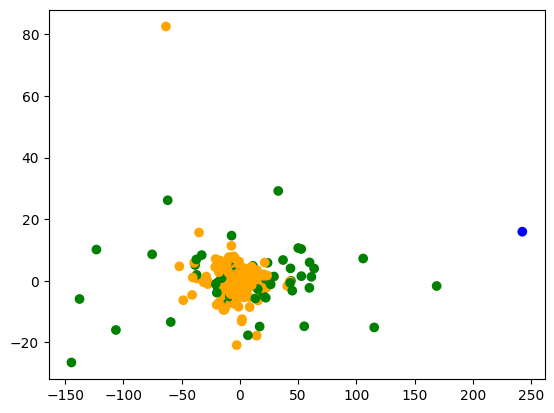

In [38]:
# 定义不同簇对应的颜色列表
colored = ['orange', 'green', 'blue', 'purple']  # 最多支持4个簇的颜色
colr = [colored[i] for i in predict]  # 列表推导式：根据每个样本的簇编号取对应颜色（str）
# 取第1列和第19列主成分绘制散点图（可调整列索引以选择不同维度）
plt.scatter(x[:, 1], x[:, 19], color=colr)
# plt.scatter 参数说明：
#   x[:,1]: 所有样本第1列特征，作为横坐标（x 轴）
#   x[:,19]: 所有样本第19列特征，作为纵坐标（y 轴）
#   color=colr: 每个点的颜色列表（list of str）

## 计算轮廓系数评估聚类效果

In [39]:
# 轮廓系数（Silhouette Score）衡量聚类质量：越接近1越好，超过0.7认为效果好
silhouette_score(x, predict)
# silhouette_score 参数说明：
#   x: 特征矩阵（numpy.ndarray），形状 (n_samples, n_features)
#   predict: 聚类标签（numpy.ndarray），形状 (n_samples,)
# 返回: float，范围 [-1, 1]，值越大聚类效果越好
# 通常可通过调整 KMeans 的 n_clusters 来优化轮廓系数

0.6662662234611542

## 指定 n_clusters=3 重新聚类并评估

In [40]:
# 重新使用 n_clusters=3 训练并评估（对比不同 k 值的效果）
km = KMeans(n_clusters=3)   # 初始化聚类模型，分3个簇
km.fit(x)                   # 训练模型
predict = km.predict(x)     # 预测簇编号，返回 numpy.ndarray
print(silhouette_score(x, predict))  # 打印轮廓系数（float），评估 k=3 时的聚类质量
predict                     # 显示所有样本的簇编号数组

0.6258372788541539


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0,
       0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## 通过聚类结果回溯原始购买数据

In [41]:
cross.iloc[0]  # 取交叉表第0行（第1个用户）的数据，返回 Series
# iloc[行整数索引]: 基于位置（int）的行选取，返回该用户在134个货架类别的购买次数
# 可结合 predict 分析不同簇用户的购买偏好差异

aisle
air fresheners candles           0
asian foods                      0
baby accessories                 0
baby bath body care              0
baby food formula                0
                                ..
trash bags liners                0
vitamins supplements             0
water seltzer sparkling water    0
white wines                      0
yogurt                           1
Name: 1, Length: 134, dtype: int64

## 查看特定用户的聚类标签与购买记录

In [42]:
predict[26]      # 查看第26个用户（索引26）被分配到哪个簇（int）
cross.iloc[26]   # 查看该用户在各货架类别的购买次数（Series），结合簇编号理解该类群偏好

aisle
air fresheners candles             0
asian foods                        4
baby accessories                   0
baby bath body care                0
baby food formula                  0
                                ... 
trash bags liners                  0
vitamins supplements               0
water seltzer sparkling water     92
white wines                        0
yogurt                           150
Name: 27, Length: 134, dtype: int64

## 再次评估 n_clusters=3 的轮廓系数

In [43]:
# 使用相同参数重复实验，观察结果稳定性（KMeans 有随机初始化，每次结果可能略有不同）
km = KMeans(n_clusters=3)   # 重新初始化 KMeans
km.fit(x)                   # 训练
predict = km.predict(x)     # 预测
silhouette_score(x, predict)  # 返回轮廓系数（float），对比前几次结果判断稳定性

0.6446000143615416

# 四种异常值检测的方法

## 1.基于分位数找异常值

## 生成随机数据并添加异常值（分位数方法准备）

In [44]:
import numpy as np
np.random.seed(42)           # 设置随机种子（int），保证每次生成相同的随机数
X = np.random.rand(50, 1)   # 生成形状 (50,1) 的二维数组，值在 [0,1) 均匀分布
X                           # 展示生成的数据

array([[0.37454012],
       [0.95071431],
       [0.73199394],
       [0.59865848],
       [0.15601864],
       [0.15599452],
       [0.05808361],
       [0.86617615],
       [0.60111501],
       [0.70807258],
       [0.02058449],
       [0.96990985],
       [0.83244264],
       [0.21233911],
       [0.18182497],
       [0.18340451],
       [0.30424224],
       [0.52475643],
       [0.43194502],
       [0.29122914],
       [0.61185289],
       [0.13949386],
       [0.29214465],
       [0.36636184],
       [0.45606998],
       [0.78517596],
       [0.19967378],
       [0.51423444],
       [0.59241457],
       [0.04645041],
       [0.60754485],
       [0.17052412],
       [0.06505159],
       [0.94888554],
       [0.96563203],
       [0.80839735],
       [0.30461377],
       [0.09767211],
       [0.68423303],
       [0.44015249],
       [0.12203823],
       [0.49517691],
       [0.03438852],
       [0.9093204 ],
       [0.25877998],
       [0.66252228],
       [0.31171108],
       [0.520

## 查看数据形状

In [45]:
X.shape  # 返回 (50, 1) 的元组，50个样本，1个特征（一维列向量）

(50, 1)

## 手动插入异常值

In [46]:
X[0, 0] = 3  # 将第0行第0列的值设为3（远超正常范围[0,1]，作为异常值）
X[1, 0] = 2  # 将第1行第0列的值设为2（同样超出正常范围，作为另一个异常值）

## 使用分位数（IQR）方法检测异常值

In [47]:
import pandas as pd

# 将 numpy 数组转为 DataFrame，便于使用 pandas 的 quantile 方法
df = pd.DataFrame(X, columns=['column_name'])
# pd.DataFrame 参数：
#   X: 数据源（numpy.ndarray），形状 (n_samples, n_features)
#   columns: 列名列表（list of str）

# 计算第一四分位数（Q1，25%分位数）
Q1 = df['column_name'].quantile(0.25)  # 返回 float，数据中25%的值低于此数
# 计算第三四分位数（Q3，75%分位数）
Q3 = df['column_name'].quantile(0.75)  # 返回 float，数据中75%的值低于此数

# 计算四分位距 IQR（Interquartile Range）
IQR = Q3 - Q1  # IQR = Q3 - Q1，代表中间50%数据的分布宽度（float）
# 通常将 < Q1-1.5*IQR 或 > Q3+1.5*IQR 的值判定为异常值（箱线图准则）

,column_name,outlier
0,3.0,Yes
1,2.0,Yes


## 3.基于DBSCAN算法找异常值

## 使用 DBSCAN 算法检测异常值（噪声点）

(1500, 2)
--------------------------------------------------
(1600, 2)


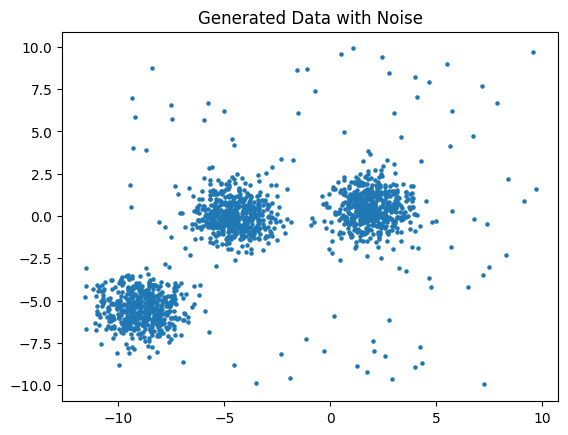

In [48]:
from sklearn.cluster import DBSCAN          # 导入 DBSCAN 密度聚类算法
import numpy as np                          # 导入 NumPy 用于数组操作
import matplotlib.pyplot as plt             # 导入 Matplotlib 用于可视化
from sklearn.datasets import make_blobs     # 导入 make_blobs，生成多中心聚类数据

# 生成模拟数据集
n_samples = 1500    # 总样本数（int）
random_state = 170  # 随机种子（int），保证可重现
X, y = make_blobs(n_samples=n_samples, random_state=random_state)
# make_blobs: 生成高斯分布的聚类数据集
#   返回: X 特征矩阵（ndarray，形状 (1500,2)）；y 标签（此处不使用，因为是无监督检测）

## 查看 make_blobs 生成的标签

In [49]:
y  # 显示 make_blobs 生成的簇标签（numpy.ndarray），值为 0/1/2，但异常值检测中不使用

array([1, 1, 0, ..., 2, 2, 2])

## 查看数据集前5个样本

In [50]:
X[0:5]  # 切片查看前5个样本，返回形状 (5, 2) 的 ndarray，每个样本有2个特征

array([[ -5.19811282,   0.64186932],
       [ -5.75229538,   0.41862711],
       [-10.84489837,  -7.55352273],
       [ -4.57098483,  -0.80101741],
       [ -3.51916215,   0.0393449 ]])

## DBSCAN 拟合并识别异常点（噪声点）

[-1  0  1  2]
[False False  True False False]
131
[0 1 2]


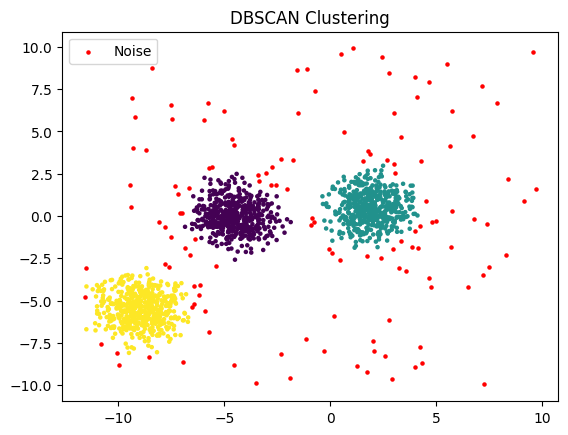

In [51]:
# 使用 DBSCAN 算法聚类，标签为 -1 的点即为噪声/异常点
db = DBSCAN(eps=0.5, min_samples=5).fit(X)
# DBSCAN 参数说明：
#   eps=0.5: 邻域半径（float），两点距离 <= eps 认为相互可达
#   min_samples=5: 核心点最少邻居数（int），邻域内样本数 >= min_samples 才是核心点
labels = db.labels_  # 获取每个样本的簇标签（numpy.ndarray），-1 表示噪声点
print(np.unique(labels))  # 打印唯一标签值，如 [-1 0 1 2]，-1代表异常，0/1/2代表簇
# 创建噪声点的布尔掩码
noise_mask = (labels == -1)  # 布尔数组（numpy.ndarray），True 表示该点为噪声
print(noise_mask[0:5])       # 查看前5个点是否为噪声
print(np.sum(noise_mask))    # 统计噪声点总数（int）
print(np.unique(labels[~noise_mask]))  # ~ 取反，显示非噪声点的簇编号

## 使用 Isolation Forest 检测异常值

[-1  1]


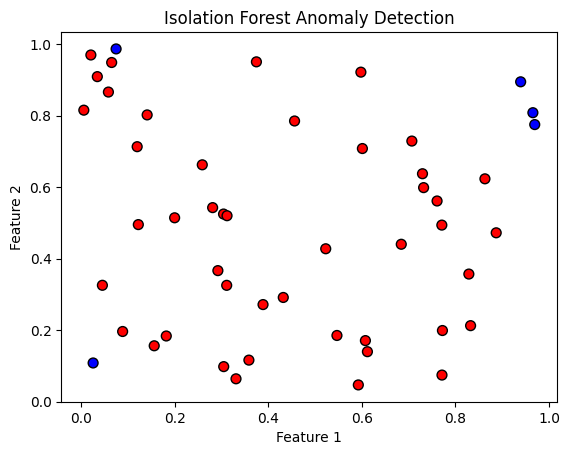

In [52]:
import numpy as np
from sklearn.ensemble import IsolationForest  # 导入孤立森林异常检测器
import matplotlib.pyplot as plt

# 生成50个正常数据点（二维特征）
np.random.seed(42)           # 随机种子，保证可重现
X = np.random.rand(50, 2)   # 形状 (50, 2) 的均匀分布数组，值在 [0,1)

# 初始化孤立森林模型
iso_forest = IsolationForest(contamination=0.1, random_state=42)
# IsolationForest 参数说明：
#   contamination=0.1: 预期异常值占比（float，0~0.5），决定判断阈值
#   random_state=42: 随机种子（int），保证结果可重现
scores = iso_forest.fit_predict(X)
# fit_predict: 先拟合再预测，返回 numpy.ndarray，形状 (n_samples,)
#   值为 1（正常点）或 -1（异常点）
labels = scores.copy()  # 复制预测结果用于后续分析

## 合并特征、异常分数与标签为 DataFrame

In [53]:
# 将特征矩阵 X、异常分数 scores 和标签 labels 拼接为一个 DataFrame，便于分析
df = pd.DataFrame(np.c_[X, scores, labels],
                  columns=['Feature 1', 'Feature 2', 'scores', 'labels'])
# np.c_: 按列拼接多个数组（类似 hstack）
#   X: 形状 (50,2)；scores: 形状 (50,1)；labels: 形状 (50,1）
#   拼接后形状 (50, 4)
# columns: 列名列表（list of str）
df  # 展示完整的 DataFrame，labels=-1 的行即为检测出的异常值

,Feature 1,Feature 2,scores,labels
0,0.374540,0.950714,0.001053,1.0
1,0.731994,0.598658,0.100556,1.0
2,0.156019,0.155995,0.053615,1.0
3,0.058084,0.866176,0.050242,1.0
4,0.601115,0.708073,0.071848,1.0
5,0.020584,0.969910,0.004049,1.0
6,0.832443,0.212339,0.019976,1.0
7,0.181825,0.183405,0.062738,1.0
8,0.304242,0.524756,0.108842,1.0
9,0.431945,0.291229,0.078362,1.0


## 筛选出所有异常点的标签

In [54]:
labels[labels == -1]  # 布尔索引筛选值为 -1 的元素，返回异常点的标签数组（numpy.ndarray）
# 结果数组的长度即为检测出的异常点数量

array([-1, -1, -1, -1, -1])